In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time
import os

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade
FIXED_END = int(pd.Timestamp('2026-07-05').timestamp() * 1000)
NUM_CANDLES = 20_000
TRAIN_END = NUM_CANDLES // 2

In [3]:
def get_historical_data(symbol, interval='60', num_candles=NUM_CANDLES, end=FIXED_END):
    
    # for live data, pass end=int(time.time() * 1000) as an argument
    
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def get_turnover_24h(symbol, end=FIXED_END):
    url = 'https://api.bybit.com/v5/market/kline'
    params = {
        'category': 'spot',
        'symbol': symbol,
        'interval': '60',
        'limit': 24,
        'end': end
    }
    r = requests.get(url, params=params)
    data = r.json()['result']['list']
    time.sleep(0.01)
    return sum(float(c[6]) for c in data)

def backtest(price_a, price_b, zscore, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    equity_history = []

    for i in range(1, len(zscore)):
        if position == 0 and zscore[i] > 2:
            position = -1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == 0 and zscore[i] < -2:
            position = 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == -1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (entry_price_a - price_a[i])
            pnl += units_b * (price_b[i] - entry_price_b)
            pnl -= fee_rate * capital * 4
            position = 0
        elif position == 1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (price_a[i] - entry_price_a)
            pnl += units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * capital * 4
            position = 0

        if position != 0:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            unrealised = position * units_a * (price_a[i] - entry_price_a)
            unrealised += position * units_b * (entry_price_b - price_b[i])
            equity_history.append(capital * 2 + pnl + unrealised)
        else:
            equity_history.append(capital * 2 + pnl)

    if position != 0:
        equity_history[-1] -= fee_rate * capital * 4
    return equity_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))

    if n < NUM_CANDLES:
        print(f"insufficient data for {symbol_a}|{symbol_b}")
        return 
        
    price_a = price_a[:n]
    price_b = price_b[:n]

    price_a_train = price_a[:TRAIN_END]
    price_b_train = price_b[:TRAIN_END]
    
    _, pvalue, _ = coint(price_a_train, price_b_train)
    if pvalue > 0.05:
        print(f"not cointegrated in training period, skipping")
        return
    print(f"cointegration p-value (train): {pvalue:.4f}")
    
    beta = np.cov(price_a_train, price_b_train)[0, 1] / np.var(price_b_train, ddof=1) 
    alpha = np.mean(price_a_train) - beta * np.mean(price_b_train)
    spread_train = price_a_train - alpha - beta * price_b_train

    timestamps_test = df_a['timestamp'][TRAIN_END:NUM_CANDLES]
    price_a_test = price_a[TRAIN_END:NUM_CANDLES]
    price_b_test = price_b[TRAIN_END:NUM_CANDLES]
    spread_test = price_a_test - alpha - beta * price_b_test
    zscore = (spread_test - spread_train.mean()) / spread_train.std()

    equity_history = backtest(price_a_test, price_b_test, zscore, capital=CAPITAL)
    days = len(price_a_test) // 24
    total_pnl = equity_history[-1] - CAPITAL * 2
    print(f"total pnl: ${total_pnl:.2f} over {days} days")
    print(f"daily pnl: ${total_pnl/days:.2f}/day")

    returns = np.diff(equity_history)
    if np.std(returns) == 0:
        print("sharpe ratio undefined (no closed trades)")
    else:
        sharpe = (np.mean(returns) / np.std(returns) * np.sqrt(24 * 365))
        print(f"sharpe ratio: {sharpe:.2f}")

    peak = np.maximum.accumulate(equity_history)
    drawdown = np.array(equity_history) - peak
    max_dd_pct = np.min(drawdown) / (CAPITAL * 2) * 100
    print(f"max drawdown: {max_dd_pct:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps_test, price_a_test / price_a_test[0], label=symbol_a)
    axes[0, 0].plot(timestamps_test, price_b_test / price_b_test[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps_test, spread_test)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps_test, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps_test[1:], equity_history)
    axes[1, 1].axhline(CAPITAL * 2, color='gray', linestyle=':')
    axes[1, 1].set_title('equity')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

599
['SOLEUR', 'BTCUSD1', 'COMPUSDT', 'ESEUSDT', 'FLOKIUSDT', 'ORDERUSDT', 'KMNOUSDT', 'ALGOUSDT', 'ADAUSDC', 'ZENTUSDT', 'RENDERUSDT', 'NEIROCTOUSDT', 'ENJUSDT', 'VIRTUALMNT', 'TOWNSUSDC', 'CELOUSDT', 'VANAUSDT', 'ROSEUSDT', 'LUNAUSDT', 'MNTUSDC', 'ZROUSDC', 'BMTUSDT', 'RUNEUSDT', 'FRAXUSDT', 'COREUSDT', 'ESUSDT', 'ZROUSDT', 'HNTUSDT', 'ENAUSDT', 'ENSUSDT', 'SAHARAUSDT', 'BBSOLUSDC', 'ICPUSDT', 'ELIZAOSUSDT', 'CBKUSDT', 'AXLUSDT', 'COINXUSDT', 'CHIPUSDT', 'BTCUSDE', 'CCUSDC', 'MONUSDT', 'WLDUSDC', 'C98USDT', 'TRUMPUSDT', 'BTCEUR', 'LTCMNT', 'WIFUSDC', 'XRPRLUSD', 'HFTUSDT', 'SOLBTC']


In [5]:
btc = get_historical_data('BTCUSDT', num_candles=5_000, end=FIXED_END)
eth = get_historical_data('ETHUSDT', num_candles=5_000, end=FIXED_END)
sol = get_historical_data('SOLUSDT', num_candles=5_000, end=FIXED_END)
btc.head()

,timestamp,close
0,2025-12-08 17:00:00,90252.9
1,2025-12-08 18:00:00,89912.0
2,2025-12-08 19:00:00,90117.2
3,2025-12-08 20:00:00,90791.8
4,2025-12-08 21:00:00,91303.6


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.3254
BTC|SOL: 0.9002
ETH|SOL: 0.7418


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

432
['COMPUSDT', 'ESEUSDT', 'FLOKIUSDT', 'ORDERUSDT', 'KMNOUSDT', 'ALGOUSDT', 'ZENTUSDT', 'RENDERUSDT', 'NEIROCTOUSDT', 'ENJUSDT', 'CELOUSDT', 'VANAUSDT', 'ROSEUSDT', 'LUNAUSDT', 'BMTUSDT', 'RUNEUSDT', 'FRAXUSDT', 'COREUSDT', 'ESUSDT', 'ZROUSDT', 'HNTUSDT', 'ENAUSDT', 'ENSUSDT', 'SAHARAUSDT', 'ICPUSDT', 'ELIZAOSUSDT', 'CBKUSDT', 'AXLUSDT', 'COINXUSDT', 'CHIPUSDT', 'MONUSDT', 'C98USDT', 'TRUMPUSDT', 'HFTUSDT', 'ARKMUSDT', 'MEWUSDT', 'WEMIXUSDT', 'VOOIUSDT', 'DIAMUSDT', 'STREAMUSDT', 'BABY1USDT', 'IMXUSDT', 'FILUSDT', 'ZEREBROUSDT', 'BATUSDT', 'FLOWUSDT', 'HPOS10IUSDT', 'RPLUSDT', 'VETUSDT', 'AZTECUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'SOLEUR', 'bid1Price': '68.18', 'bid1Size': '0.4', 'ask1Price': '68.24', 'ask1Size': '0.6308', 'lastPrice': '68.22', 'prevPrice24h': '67.25', 'price24hPcnt': '0.0144', 'highPrice24h': '68.91', 'lowPrice24h': '67.2', 'turnover24h': '120474.421871', 'volume24h': '1775.5129'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

76
['ZROUSDT', 'ENAUSDT', 'ICPUSDT', 'COINXUSDT', 'MONUSDT', 'GRASSUSDT', 'GRAMUSDT', 'JTOUSDT', 'HUSDT', 'WLDUSDT', 'BASEDUSDT', 'TRXUSDT', 'EGLDUSDT', 'CRCLXUSDT', 'CCUSDT', 'GROVEUSDT', 'XPLUSDT', 'AEROUSDT', 'INJUSDT', 'SPCXXUSDT', 'ARXUSDT', 'XAUTUSDT', 'USD1USDT', 'AVAXUSDT', 'ASTERUSDT', 'VVVUSDT', 'MNTUSDT', 'SENTUSDT', 'USDCUSDT', 'APEUSDT', 'TRIAUSDT', 'LTCUSDT', 'DOTUSDT', 'OPUSDT', 'NEARUSDT', 'BNBUSDT', 'BONKUSDT', 'OPGUSDT', 'USDEUSDT', 'EIGENUSDT', 'BIRBUSDT', 'LITUSDT', 'UNIUSDT', 'AAVEUSDT', 'TIAUSDT', 'HBARUSDT', 'BLURUSDT', 'SHIBUSDT', 'SOLUSDT', 'HOODXUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker, num_candles=NUM_CANDLES)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            if n < NUM_CANDLES:
                continue
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:TRAIN_END], data_filt[b]['close'].iloc[:TRAIN_END])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

     ticker_a   ticker_b        pvalue
132   WLDUSDT  ETHFIUSDT  5.100095e-09
311  USDCUSDT   ONDOUSDT  9.239630e-08
304  USDCUSDT    UNIUSDT  1.336631e-07
316  USDCUSDT    LDOUSDT  1.401487e-07
302  USDCUSDT    BNBUSDT  1.410687e-07
305  USDCUSDT   AAVEUSDT  1.559157e-07
307  USDCUSDT   HBARUSDT  1.611443e-07
312  USDCUSDT   LINKUSDT  1.650412e-07
323  USDCUSDT    ETHUSDT  1.877129e-07
315  USDCUSDT  ETHFIUSDT  1.990682e-07
310  USDCUSDT    SOLUSDT  2.064726e-07
322  USDCUSDT   PEPEUSDT  2.141565e-07
320  USDCUSDT    XRPUSDT  2.160082e-07
317  USDCUSDT   DOGEUSDT  2.224551e-07
298  USDCUSDT    LTCUSDT  2.256257e-07
321  USDCUSDT    SUIUSDT  2.268375e-07
303  USDCUSDT   BONKUSDT  2.277558e-07
314  USDCUSDT  VANRYUSDT  2.284038e-07
319  USDCUSDT    XLMUSDT  2.294759e-07
318  USDCUSDT    ARBUSDT  2.332602e-07


In [11]:
print(len(strong))
print(strong.to_string())

83
      ticker_a   ticker_b        pvalue
132    WLDUSDT  ETHFIUSDT  5.100095e-09
311   USDCUSDT   ONDOUSDT  9.239630e-08
304   USDCUSDT    UNIUSDT  1.336631e-07
316   USDCUSDT    LDOUSDT  1.401487e-07
302   USDCUSDT    BNBUSDT  1.410687e-07
305   USDCUSDT   AAVEUSDT  1.559157e-07
307   USDCUSDT   HBARUSDT  1.611443e-07
312   USDCUSDT   LINKUSDT  1.650412e-07
323   USDCUSDT    ETHUSDT  1.877129e-07
315   USDCUSDT  ETHFIUSDT  1.990682e-07
310   USDCUSDT    SOLUSDT  2.064726e-07
322   USDCUSDT   PEPEUSDT  2.141565e-07
320   USDCUSDT    XRPUSDT  2.160082e-07
317   USDCUSDT   DOGEUSDT  2.224551e-07
298   USDCUSDT    LTCUSDT  2.256257e-07
321   USDCUSDT    SUIUSDT  2.268375e-07
303   USDCUSDT   BONKUSDT  2.277558e-07
314   USDCUSDT  VANRYUSDT  2.284038e-07
319   USDCUSDT    XLMUSDT  2.294759e-07
318   USDCUSDT    ARBUSDT  2.332602e-07
297   USDCUSDT    APEUSDT  2.353618e-07
313   USDCUSDT    ADAUSDT  2.360153e-07
308   USDCUSDT   BLURUSDT  2.362167e-07
300   USDCUSDT     OPUSDT  2.363309e-

In [12]:
tickers_liquid = [t for t in tickers_usdt if get_turnover_24h(t) > 5_000_000]
print(len(tickers_liquid))
print(tickers_liquid)

17
['GRAMUSDT', 'XPLUSDT', 'VVVUSDT', 'MNTUSDT', 'USDCUSDT', 'LITUSDT', 'SOLUSDT', 'SLXUSDT', 'ADAUSDT', 'TACUSDT', 'DOGEUSDT', 'XRPUSDT', 'HMSTRUSDT', 'CAPUSDT', 'HYPEUSDT', 'ETHUSDT', 'BTCUSDT']


In [13]:
os.makedirs('data', exist_ok=True)

data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker, num_candles=NUM_CANDLES, end=FIXED_END)

for symbol, df in data_liquid.items():
    df.to_csv(f'data/{symbol}.csv', index=False)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            if n < NUM_CANDLES:
                continue
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:TRAIN_END], data_liquid[b]['close'].iloc[:TRAIN_END])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong_liquid = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
strong_filt = strong_liquid[(strong_liquid['ticker_a'] != 'USDCUSDT') & (strong_liquid['ticker_b'] != 'USDCUSDT')] # USDCUSDT is a stablecoin pegged to US dollar (spread reduces to mean reversion)
print(len(strong_filt))
print(strong_filt.to_string())

2
    ticker_a  ticker_b    pvalue
6   GRAMUSDT   ETHUSDT  0.045049
22   SOLUSDT  DOGEUSDT  0.031540


GRAMUSDT|ETHUSDT
cointegration p-value (train): 0.0450
total pnl: $-107.85 over 416 days
daily pnl: $-0.26/day
sharpe ratio: -0.10
max drawdown: -53.78%


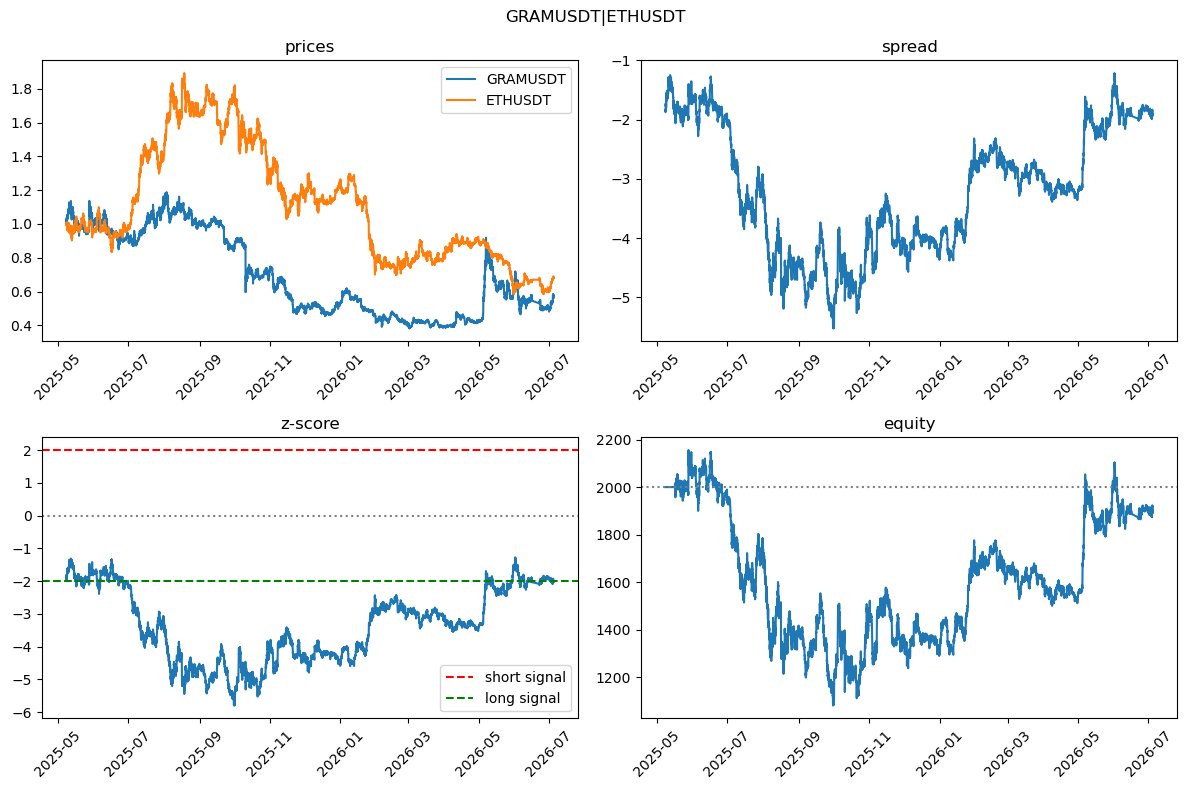

SOLUSDT|DOGEUSDT
cointegration p-value (train): 0.0315
total pnl: $13.41 over 416 days
daily pnl: $0.03/day
sharpe ratio: 0.04
max drawdown: -24.65%


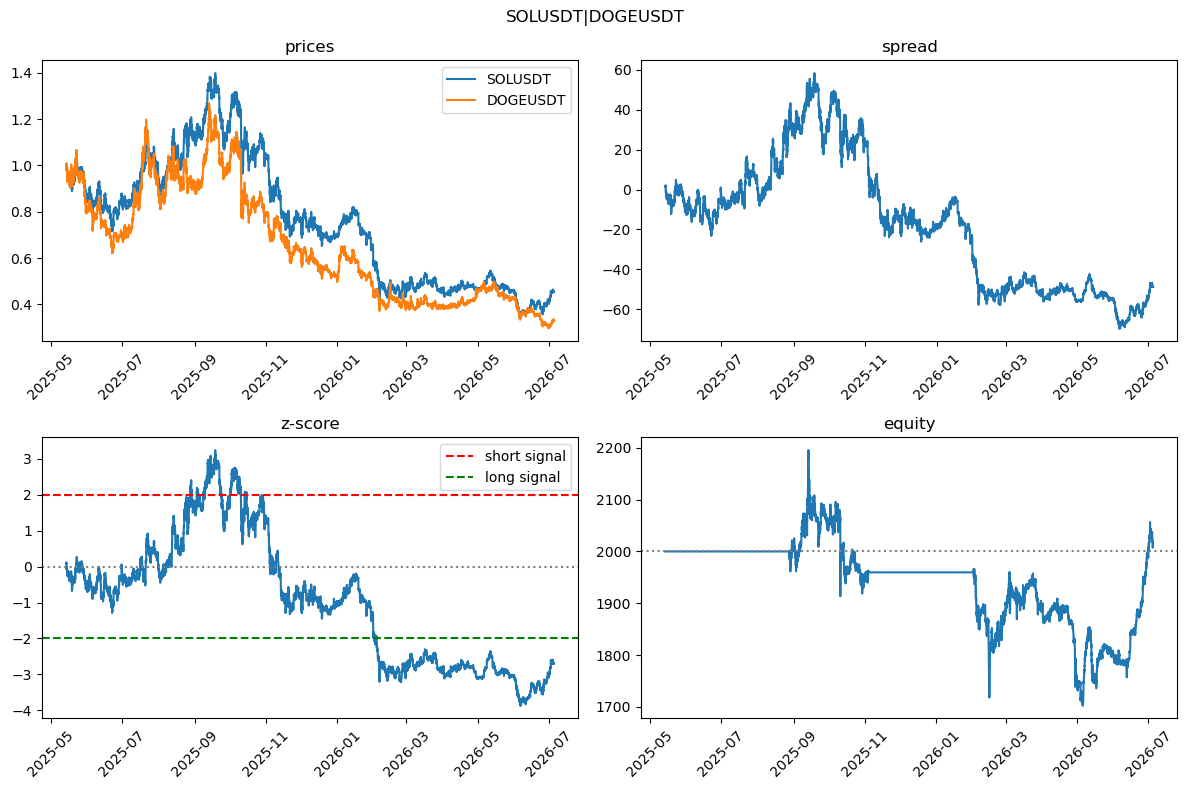

In [14]:
for ticker_a, ticker_b in zip(strong_filt['ticker_a'], strong_filt['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)